In [1]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

In [2]:
data=pd.read_csv('heart.csv')

In [3]:
data

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [4]:
data.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [5]:
data.duplicated().sum()

np.int64(0)

<Axes: xlabel='HeartDisease'>

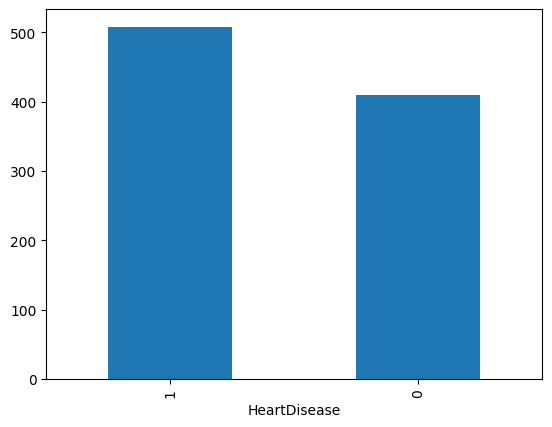

In [6]:
data['HeartDisease'].value_counts().plot(kind='bar')

In [7]:
data.isnull()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
913,False,False,False,False,False,False,False,False,False,False,False,False
914,False,False,False,False,False,False,False,False,False,False,False,False
915,False,False,False,False,False,False,False,False,False,False,False,False
916,False,False,False,False,False,False,False,False,False,False,False,False


In [8]:
data.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

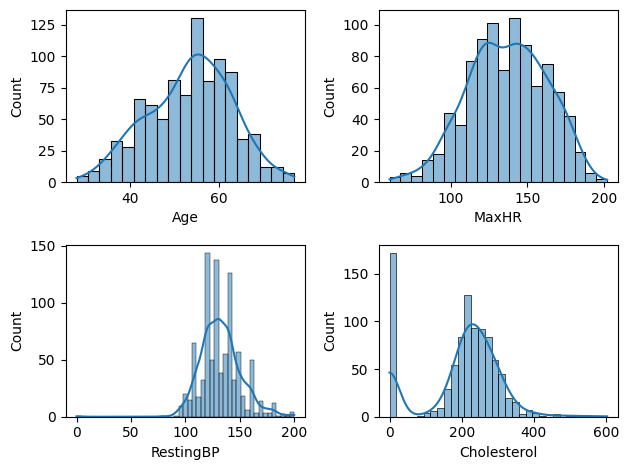

In [9]:
def plotting(var,num):
    plt.subplot(2,2,num)
    sns.histplot(data=data ,x=var,kde=True)

plotting('Age',1)
plotting('MaxHR',2)
plotting('RestingBP',3)
plotting('Cholesterol',4)   
plt.tight_layout() 

In [10]:
ch_mean=data.loc[data['Cholesterol']!=0,'Cholesterol'].mean()

In [11]:
data['Cholesterol']=data['Cholesterol'].replace(0,ch_mean)
data['Cholesterol']=data['Cholesterol'].round(2)

In [12]:

rb_mean=data.loc[data['RestingBP']!=0,'RestingBP'].mean()
data['RestingBP']=data['RestingBP'].replace(0,rb_mean)
data['RestingBP']=data['RestingBP'].round(2)

In [13]:
data

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140.0,289.0,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160.0,180.0,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130.0,283.0,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138.0,214.0,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150.0,195.0,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110.0,264.0,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144.0,193.0,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130.0,131.0,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130.0,236.0,0,LVH,174,N,0.0,Flat,1


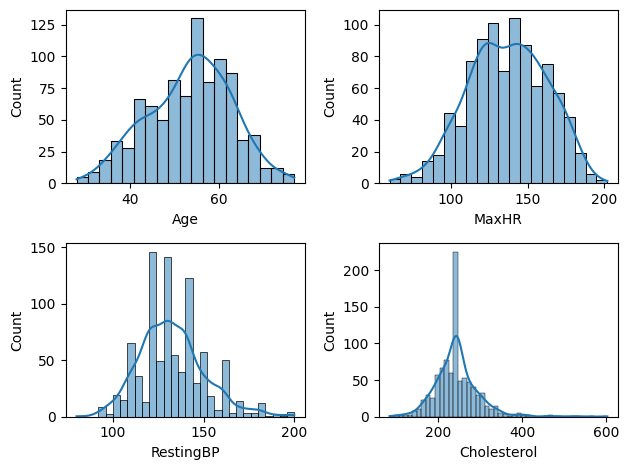

In [14]:
def plotting(var,num):
    plt.subplot(2,2,num)
    sns.histplot(data=data ,x=var,kde=True)

plotting('Age',1)
plotting('MaxHR',2)
plotting('RestingBP',3)
plotting('Cholesterol',4)   
plt.tight_layout()

<Axes: xlabel='ChestPainType', ylabel='count'>

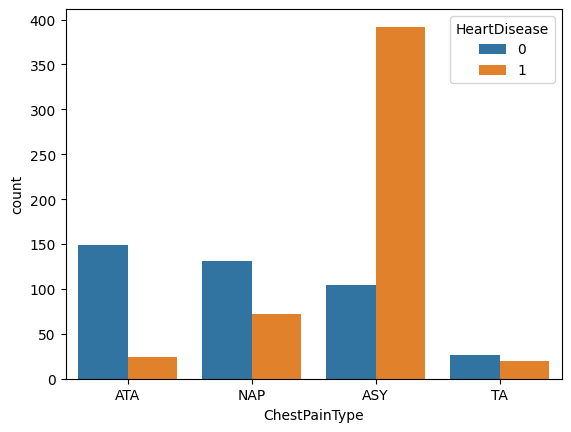

In [15]:
sns.countplot(x=data['ChestPainType'],hue=data['HeartDisease'])

In [16]:
df_encode=pd.get_dummies(data,drop_first=True)
df_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140.0,289.0,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160.0,180.0,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130.0,283.0,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138.0,214.0,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150.0,195.0,0,122,0.0,0,True,False,True,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110.0,264.0,0,132,1.2,1,True,False,False,True,True,False,False,True,False
914,68,144.0,193.0,1,141,3.4,1,True,False,False,False,True,False,False,True,False
915,57,130.0,131.0,0,115,1.2,1,True,False,False,False,True,False,True,True,False
916,57,130.0,236.0,0,174,0.0,1,False,True,False,False,False,False,False,True,False


In [17]:
df_encode=df_encode.astype(int)
df_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0,0,1,1,0,0,1,0,0,0,1
1,49,160,180,0,156,1,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0,0,1,1,0,0,0,1,0,0,1
3,48,138,214,0,108,1,1,0,0,0,0,1,0,1,1,0
4,54,150,195,0,122,0,0,1,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110,264,0,132,1,1,1,0,0,1,1,0,0,1,0
914,68,144,193,1,141,3,1,1,0,0,0,1,0,0,1,0
915,57,130,131,0,115,1,1,1,0,0,0,1,0,1,1,0
916,57,130,236,0,174,0,1,0,1,0,0,0,0,0,1,0


In [18]:
df_encode.columns

Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease', 'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP',
       'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST',
       'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up'],
      dtype='object')

In [19]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,f1_score,classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [21]:
X=df_encode.drop('HeartDisease',axis=1)
y=df_encode['HeartDisease']

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [23]:
scaler=StandardScaler()
X_train_scal=scaler.fit_transform(X_train)
X_train_scal=scaler.fit_transform(X_test)

In [24]:
X_train_scal

array([[ 1.06087876e+00,  4.86897535e-01, -8.46480653e-01, ...,
        -7.93115539e-01, -9.32936424e-01,  1.10812507e+00],
       [-3.65820263e-02,  7.61116779e-01,  4.70384864e+00, ...,
        -7.93115539e-01,  1.07188440e+00, -9.02425209e-01],
       [ 1.28037092e+00,  1.58377451e+00, -4.48023393e-03, ...,
        -7.93115539e-01,  1.07188440e+00, -9.02425209e-01],
       ...,
       [-1.13404281e+00, -5.00291743e-01, -4.48023393e-03, ...,
        -7.93115539e-01, -9.32936424e-01,  1.10812507e+00],
       [-9.14550657e-01,  2.12678291e-01, -8.98031699e-01, ...,
        -7.93115539e-01, -9.32936424e-01,  1.10812507e+00],
       [ 1.06087876e+00, -1.70685642e+00, -4.48023393e-03, ...,
        -7.93115539e-01,  1.07188440e+00, -9.02425209e-01]],
      shape=(303, 15))

In [25]:
models={
    "LogisticRegression":LogisticRegression(),
    "KNN":KNeighborsClassifier(),
    "Naive Byas": GaussianNB(),
    "DecisionTree": DecisionTreeClassifier(),
    "SVM(RBF Kernel)": SVC(probability=True)

    
    
}

In [26]:
# Importing the scaler
from sklearn.preprocessing import StandardScaler

# Create the scaler object
scaler = StandardScaler()

# Fit the scaler on the training data and transform it
X_train_scal = scaler.fit_transform(X_train)

# Use the SAME scaler to transform the test data
X_test_scal = scaler.transform(X_test)

In [27]:
result = []

In [28]:
for name, model in models.items():
    model.fit(X_train_scal,y_train)
    y_pred=model.predict(X_test_scal)
    acc=accuracy_score(y_test,y_pred)
    f1=f1_score(y_test,y_pred)
    result.append({
        'Model':name,
        'Accuracy':round(acc,4),
        'F1_score': round(acc,4)
    
    })

In [29]:
result

[{'Model': 'LogisticRegression', 'Accuracy': 0.8614, 'F1_score': 0.8614},
 {'Model': 'KNN', 'Accuracy': 0.8515, 'F1_score': 0.8515},
 {'Model': 'Naive Byas', 'Accuracy': 0.8515, 'F1_score': 0.8515},
 {'Model': 'DecisionTree', 'Accuracy': 0.7393, 'F1_score': 0.7393},
 {'Model': 'SVM(RBF Kernel)', 'Accuracy': 0.8515, 'F1_score': 0.8515}]

In [30]:
%pip install pickle5

Defaulting to user installation because normal site-packages is not writeable
  Using cached pickle5-0.0.11.tar.gz (132 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
Failed to build pickle5
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × Building wheel for pickle5 (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [67 lines of output]
      C:\Users\himan\AppData\Local\Temp\pip-build-env-vr0dt211\overlay\Lib\site-packages\setuptools\dist.py:765: SetuptoolsDeprecationWarning: License classifiers are deprecated.
      !!
      
              ********************************************************************************
              Please consider removing the following classifiers in favor of a SPDX license expression:
      
              License :: OSI Approved :: Python Software Foundation License
      
              See https://packaging.python.org/en/latest/guides/writing-pyproject-toml/#license for details.
              ********************************************************************************
      
      !!
        self._finalize_license_expression()
      running bdist_wheel
      running build
      running build_py
      creating build\lib

In [31]:
import joblib

In [32]:
joblib.dump(models['KNN'],'KNN_heart.pkl')
joblib.dump(scaler,'scaler.pkl')
joblib.dump(X.columns.tolist(),'columns.pkl')

['columns.pkl']